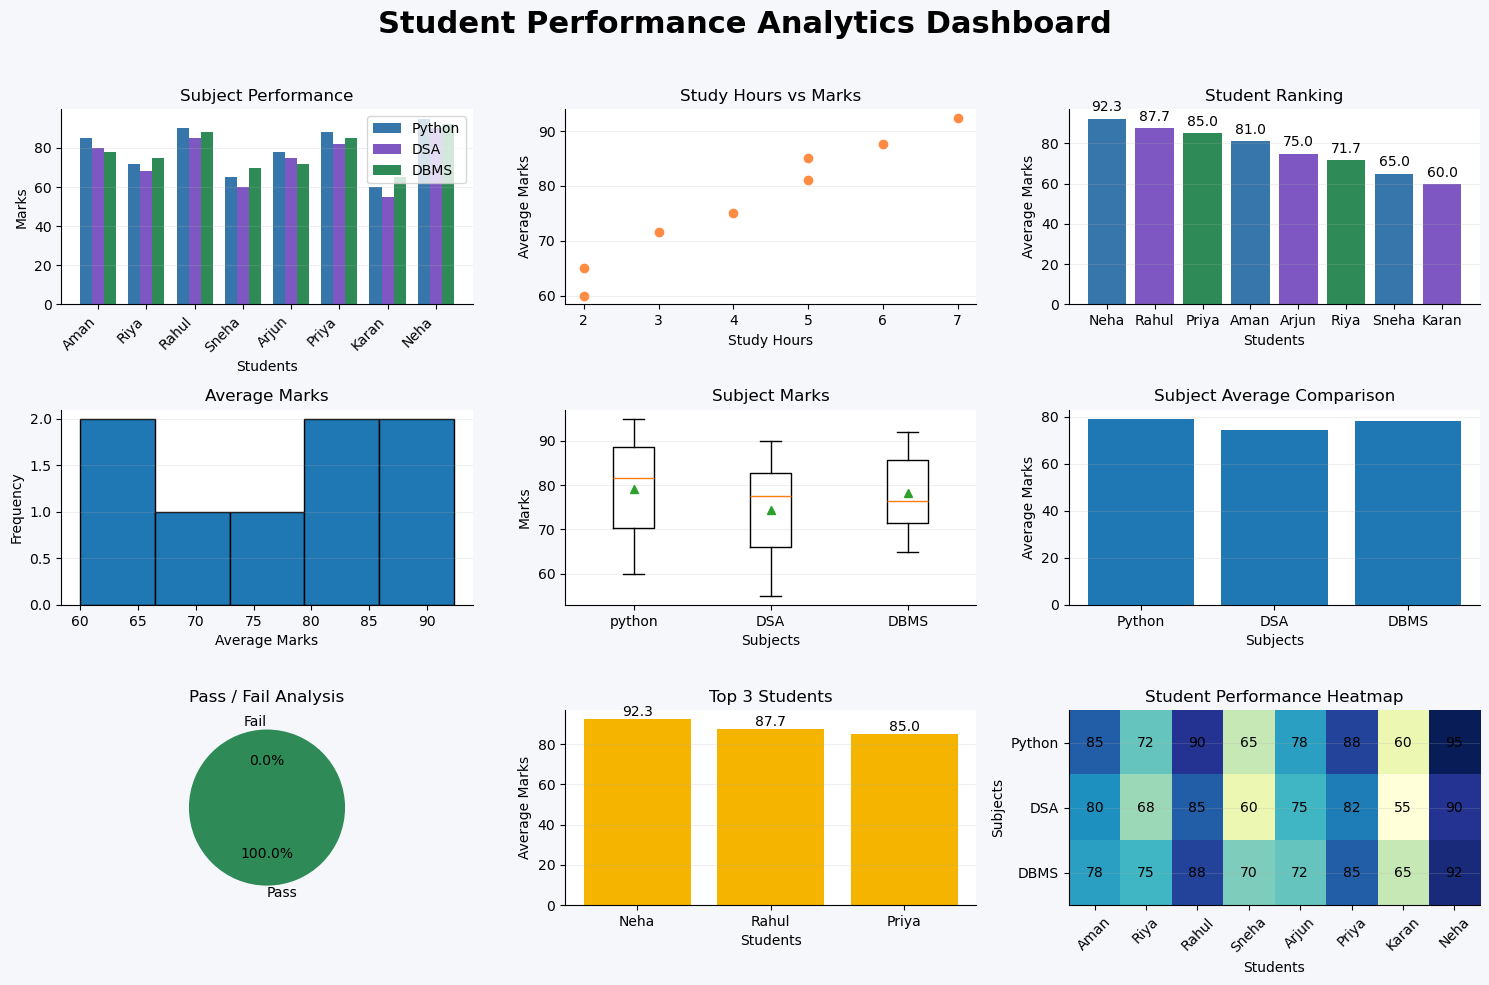

In [35]:
import matplotlib.pyplot as plt
import numpy as np

students = ["Aman", "Riya", "Rahul", "Sneha", "Arjun",
            "Priya", "Karan", "Neha"]

python_marks = [85, 72, 90, 65, 78, 88, 60, 95]
dsa_marks = [80, 68, 85, 60, 75, 82, 55, 90]
dbms_marks = [78, 75, 88, 70, 72, 85, 65, 92]

study_hours = [5, 3, 6, 2, 4, 5, 2, 7]

average_marks =[(p + ds+ db) / 3 for p,ds,db in zip(python_marks,dsa_marks,dbms_marks)]

subject_average = [
    np.mean(python_marks),
    np.mean(dsa_marks),
    np.mean(dbms_marks)
]

subjects = ["Python","DSA","DBMS"]


ranking = sorted(
    zip(students, average_marks),
    key=lambda x: x[1],
    reverse=True
)

rank_students = [x[0] for x in ranking]
rank_marks = [x[1] for x in ranking]

fig,ax = plt.subplots(3,3,figsize=(15,10))
fig.patch.set_facecolor("#F5F7FA")

x=np.arange(len(students))
width = 0.25

ax[0][0].bar(x-width,
             python_marks,
             width,
             label="Python",
             color="#3776AB"
            )

ax[0][0].bar(x,
             dsa_marks,
             width,
             label="DSA",
             color="#7E57C2"
            )

ax[0][0].bar(x+width
             ,dbms_marks,
             width,
             label="DBMS",
             color="#2E8B57"
            )

ax[0][0].set_title("Subject Performance")
ax[0][0].set_xlabel("Students")
ax[0][0].set_ylabel("Marks")
ax[0][0].set_xticks(x)
ax[0][0].set_xticklabels(
    students,
    rotation=45,
    ha="right"
)

ax[0][0].legend()

ax[0][1].scatter(study_hours, 
                 average_marks,  
                 color="#FF8C42"
                )
ax[0][1].set_title("Study Hours vs Marks")
ax[0][1].set_xlabel("Study Hours")
ax[0][1].set_ylabel("Average Marks")

bars = ax[0][2].bar(rank_students,
                    rank_marks,  
                    color=["#3776AB", "#7E57C2", "#2E8B57"]
                   )

ax[0][2].set_title("Student Ranking")
ax[0][2].set_xlabel("Students")
ax[0][2].set_ylabel("Average Marks")
ax[0][2].bar_label(
    bars,
    fmt="%.1f",
    padding=3
)

ax[1][0].hist(average_marks,
              bins=5,
              edgecolor="black"
             )

ax[1][0].set_title("Average Marks")
ax[1][0].set_xlabel("Average Marks")
ax[1][0].set_ylabel("Frequency")

ax[1][1].boxplot([python_marks,
                  dsa_marks,
                  dbms_marks],
                 tick_labels=["python","DSA","DBMS"],
                 showmeans=True
                )

ax[1][1].set_title("Subject Marks")
ax[1][1].set_xlabel("Subjects")
ax[1][1].set_ylabel("Marks")


ax[1][2].bar(subjects,
             subject_average
            )

ax[1][2].set_title("Subject Average Comparison")
ax[1][2].set_xlabel("Subjects")
ax[1][2].set_ylabel("Average Marks")
ax[1][2].grid(axis="y",alpha=0.6)



pass_marks = 40

pass_count = sum(mark >= pass_marks for mark in average_marks)
fail_count = len(average_marks) - pass_count

ax[2][0].pie(
    [pass_count, fail_count],
    labels=["Pass", "Fail"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2E8B57", "#E74C3C"]
)

ax[2][0].set_title("Pass / Fail Analysis")



top3_students = rank_students[:3]
top3_marks = rank_marks[:3]

bars = ax[2][1].bar(
    top3_students,
    top3_marks,
    color="#F4B400"
)

ax[2][1].set_title("Top 3 Students")
ax[2][1].set_xlabel("Students")
ax[2][1].set_ylabel("Average Marks")

ax[2][1].bar_label(
    bars,
    fmt="%.1f"
)

ax[2][1].grid(axis="y", alpha=0.3)



heatmap_data = np.array([
    python_marks,
    dsa_marks,
    dbms_marks
])

im = ax[2][2].imshow(
    heatmap_data,
    aspect="auto",
    cmap="YlGnBu"
)

ax[2][2].set_title("Student Performance Heatmap")
ax[2][2].set_xlabel("Students")
ax[2][2].set_ylabel("Subjects")

ax[2][2].set_xticks(range(len(students)))
ax[2][2].set_xticklabels(
    students,
    rotation=45
)

ax[2][2].set_yticks(range(3))
ax[2][2].set_yticklabels(
    ["Python", "DSA", "DBMS"]
)


for i in range(3):
    for j in range(len(students)):
        ax[2][2].text(
            j,
            i,
            heatmap_data[i, j],
            ha="center",
            va="center"
        )

fig.suptitle("Student Performance Analytics Dashboard",fontsize=22,
    fontweight="bold",
    y=0.98)

plt.tight_layout(rect=[0,0,1,0.96])

for row in ax:
    for a in row:
        a.set_facecolor("white")
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
        a.grid(axis="y", alpha=0.2)
plt.show()


